# Assignment 4

# Get the data
I am much happier with  all of these datasets that are built into SKLear and do not require any tricky navagation.  Even luckier - the data is scaled and 'pressed' into a 1D array.  


In [2]:
from sklearn.datasets import fetch_olivetti_faces
of = fetch_olivetti_faces()

# Split the data

Here we are going to divide the test and training data.  Because of the limited number of rows, we are going to stratistfy the target so we have equal test samples moving forward.

In [3]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(of.data, of.target, stratify=of.target)

## Lets look at a single picture 
It appears to be a 70 x 70 image of a person.  The cropping is not perfect, you are missing his ears, parts of his chin and forehead.

In [4]:
from matplotlib.pyplot import imshow
imshow(of.images[2], cmap='gray')

# Cluster the model
Here we import the model and begin to build the cluster.  

In [5]:
from sklearn.cluster import KMeans
kms = KMeans()
kms.fit(X_train)

KMeans()

Now we are going to search the model for different inertias.  We are going to examine all options before choosing the best choice.  

In [6]:
inretias = list()
for k in range(1, 20):
    kms = KMeans(n_clusters=k)
    kms.fit(X_train)
    inretias.append(kms.inertia_)


C:\Users\admin\Anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1037: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  "KMeans is known to have a memory leak on Windows "


The elbow appears be be right on 5.  This is the important range for when we compromise Inretia with Clusters

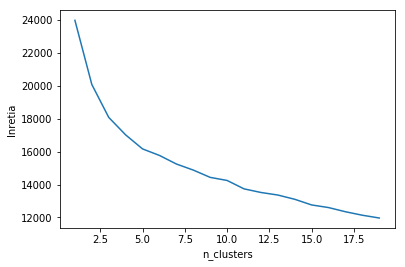

In [10]:
import matplotlib.pyplot   as plt
plt.plot(range(1, 20), inretias)
plt.xlabel('n_clusters')
plt.ylabel('Inretia')
plt.show()

# Dimention Control
tSNE is a dimention reduction package that should make the data more trainable.  

In [11]:
from sklearn.manifold import TSNE
tsne = TSNE()
X_train_reduced = tsne.fit_transform(X_train)

C:\Users\admin\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
C:\Users\admin\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


The following annotation plot speaks for itself.  You can see that people with 'similar' faces are presented in their own region on the chart.

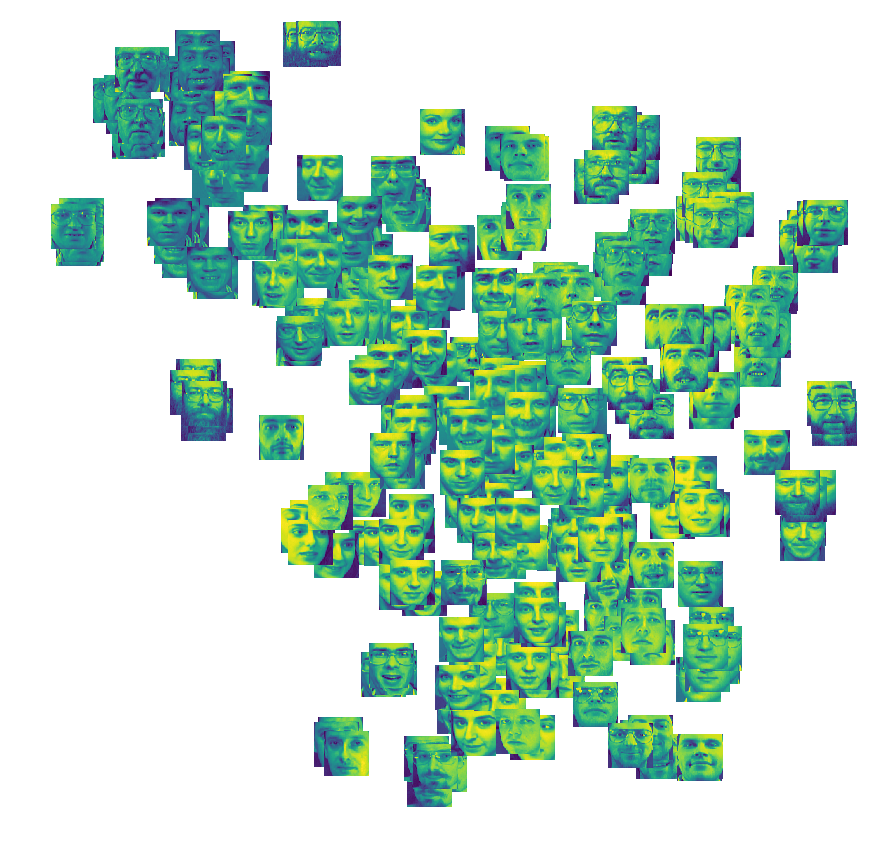

In [13]:
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(X_train_reduced[:, 0], X_train_reduced[:,1])

for idx in range(len(X_train_reduced)):
    ab = AnnotationBbox(OffsetImage(X_train[idx].reshape(64, 64), zoom=0.7), (X_train_reduced[idx, 0], X_train_reduced[idx, 1]), frameon=False)
    ax.add_artist(ab)

plt.axis('off')
plt.show()